In [33]:
import pandas as pd
import os
from utils.ml_utils_v2 import EmissionsPredictionPipeline, MultiOutputEmissionsPipeline
from utils.eda_utils import EDAUtils, DataCleaningUtils
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib
from pathlib import Path

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
SIMULATION_DIR_PATH = os.path.join(SSP_DIR_PATH, "sisepuede_run_2025-01-14T17;04;06.975301_output_database")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")

In [5]:
TRAINING_DATA_PATH = os.path.join(TRAINING_DIR_PATH, "training_data_v4.1_narrative_profiles.csv")
training_df = pd.read_csv(TRAINING_DATA_PATH)
training_df = training_df.drop(columns=["primary_id", "future_id"])
training_df.head()

,group_1_ef_lvst_entferm,group_2_yf_agrc,group_3_demscalar_soil,group_4_demscalar_ippu,group_5_efficfactor_enfu_industrial_energy_fuel,group_6_elecfuelefficiency_trns,group_7_factor_waso_waste_per_capita_scalar_food,group_8_frac_fgtv,group_9_frac_agrc_agriculture_production_lost,group_10_frac_agrc,...,group_42_pij_lndu_settlements_to,group_43_pij_lndu_wetlands_to,group_44_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_45_scalar_lvst_carrying_capacity,group_46_scalar_scoe_appliance_energy_demand,group_47_scalar_scoe_heat_energy_demand,emission_avg_last_five_years,emission_total,production_total,technical_cost
0,0.952436,0.360397,0.202990,0.995748,0.369859,0.919920,0.478450,0.445798,0.490988,0.510280,...,0.053597,0.175103,0.379422,0.438093,0.149362,0.869757,52.248688,3318.009812,19378.180701,-5.143090
1,0.304955,0.204875,0.540658,0.800192,0.206396,0.777352,0.805727,0.536048,0.779857,0.623335,...,0.246165,0.101025,0.717013,0.368791,0.774941,0.483352,49.914523,3219.904574,18029.696308,-6.899667
2,0.609262,0.366443,0.601808,0.916668,0.386475,0.181162,0.138910,0.768925,0.884425,0.232722,...,0.122444,0.653845,0.216259,0.714853,0.881270,0.581230,-5.154870,2328.191406,18788.752879,-7.129115
3,0.815313,0.487444,0.323954,0.634299,0.064625,0.926815,0.633805,0.439346,0.027114,0.532020,...,0.592915,0.564895,0.027725,0.138890,0.820709,0.250616,45.879563,3225.387997,18792.286140,-5.769771
4,0.973878,0.842718,0.884382,0.483039,0.455502,0.003343,0.571994,0.108021,0.346714,0.892123,...,0.432240,0.662820,0.179231,0.631375,0.395960,0.661637,24.993688,2740.854420,18030.008356,-8.530492


## EDA

In [6]:
edau = EDAUtils()

In [7]:
target_cols = [col for col in training_df.columns if "emission" in col] + ["technical_cost"] + ["production_total"]
target_cols

['emission_avg_last_five_years',
 'emission_total',
 'technical_cost',
 'production_total']

In [8]:
lhs_group_cols = [col for col in training_df.columns if col.startswith("group_")]
# lhs_group_cols

In [9]:
training_df[target_cols].describe()

,emission_avg_last_five_years,emission_total,technical_cost,production_total
count,9.840000e+02,9.840000e+02,9.840000e+02,984.000000
mean,2.097051e+05,7.462781e+06,1.491879e+05,18441.666220
std,2.904940e+06,9.656415e+07,1.931283e+06,952.271508
min,-8.721902e+00,2.234746e+03,-1.164369e+01,15525.560577
25%,3.063351e+01,2.880913e+03,-7.241585e+00,17806.078305
50%,4.309360e+01,3.101140e+03,-5.770438e+00,18422.339266
75%,5.654174e+01,3.321034e+03,-4.387264e+00,19056.590735
max,6.075109e+07,1.819204e+09,3.638401e+07,21281.238128


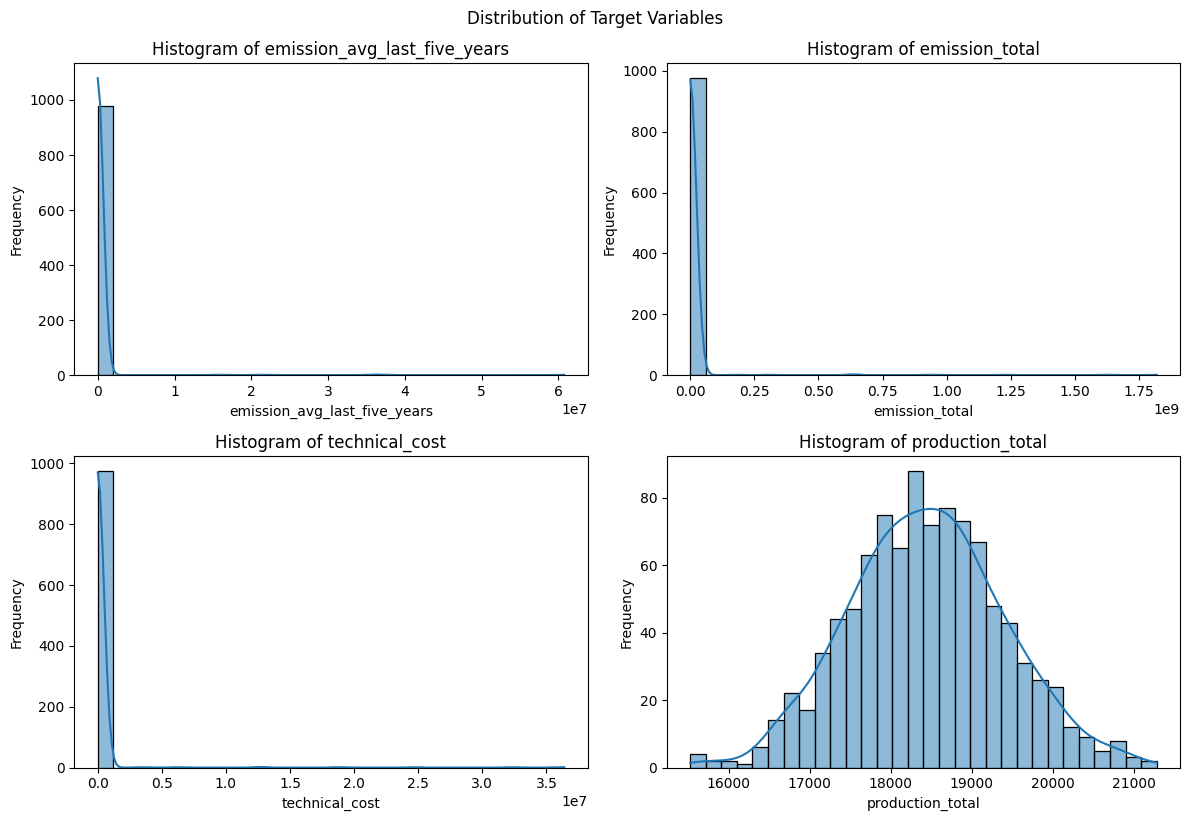

In [10]:
edau.plot_multiple_histograms(training_df, target_cols, title="Distribution of Target Variables")


In [11]:
edau.get_target_var_corr(training_df, "emission_total")
edau.get_target_var_corr(training_df, "emission_avg_last_five_years")
edau.get_target_var_corr(training_df, "technical_cost")
edau.get_target_var_corr(training_df, "production_total")


Correlation with target variable 'emission_total' (threshold: 0.1):
--------------------------------------------------
emission_total                 : 1.0000
technical_cost                 : 1.0000
emission_avg_last_five_years   : 0.5951


Correlation with target variable 'emission_avg_last_five_years' (threshold: 0.1):
--------------------------------------------------
emission_avg_last_five_years   : 1.0000
emission_total                 : 0.5951
technical_cost                 : 0.5951


Correlation with target variable 'technical_cost' (threshold: 0.1):
--------------------------------------------------
technical_cost                 : 1.0000
emission_total                 : 1.0000
emission_avg_last_five_years   : 0.5951


Correlation with target variable 'production_total' (threshold: 0.1):
--------------------------------------------------
production_total               : 1.0000
group_17_frac_trns_fuelmix     : 0.5262
group_12_frac_enfu_transmission_loss_fuel_electricity : 0.456


Correlation with target variable 'technical_cost' (threshold: 0.1):
--------------------------------------------------
technical_cost                 : 1.0000
emission_total                 : 1.0000
emission_avg_last_five_years   : 0.5951



In [12]:
# Find constant / near-constant cols
const_cols = edau.find_constant_columns(training_df)
near_const_cols = edau.find_near_constant_columns(training_df, threshold=1e-2)
print("Constant:", const_cols)
print("Near-constant:", near_const_cols)

Constant: []
Near-constant: []


In [13]:
# Outlier inspection
outliers = edau.find_outlier_columns(training_df, z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {'emission_avg_last_five_years': 0.6097560975609756, 'emission_total': 0.7113821138211381, 'production_total': 0.10162601626016261, 'technical_cost': 0.7113821138211381}


## Data Cleaning

In [14]:
dcu = DataCleaningUtils()

In [15]:
training_df.shape

(984, 50)

In [16]:
training_df_cleaned = dcu.remove_outliers(training_df)
print("Shape after removing outliers:", training_df_cleaned.shape)

Shape after removing outliers: (975, 50)


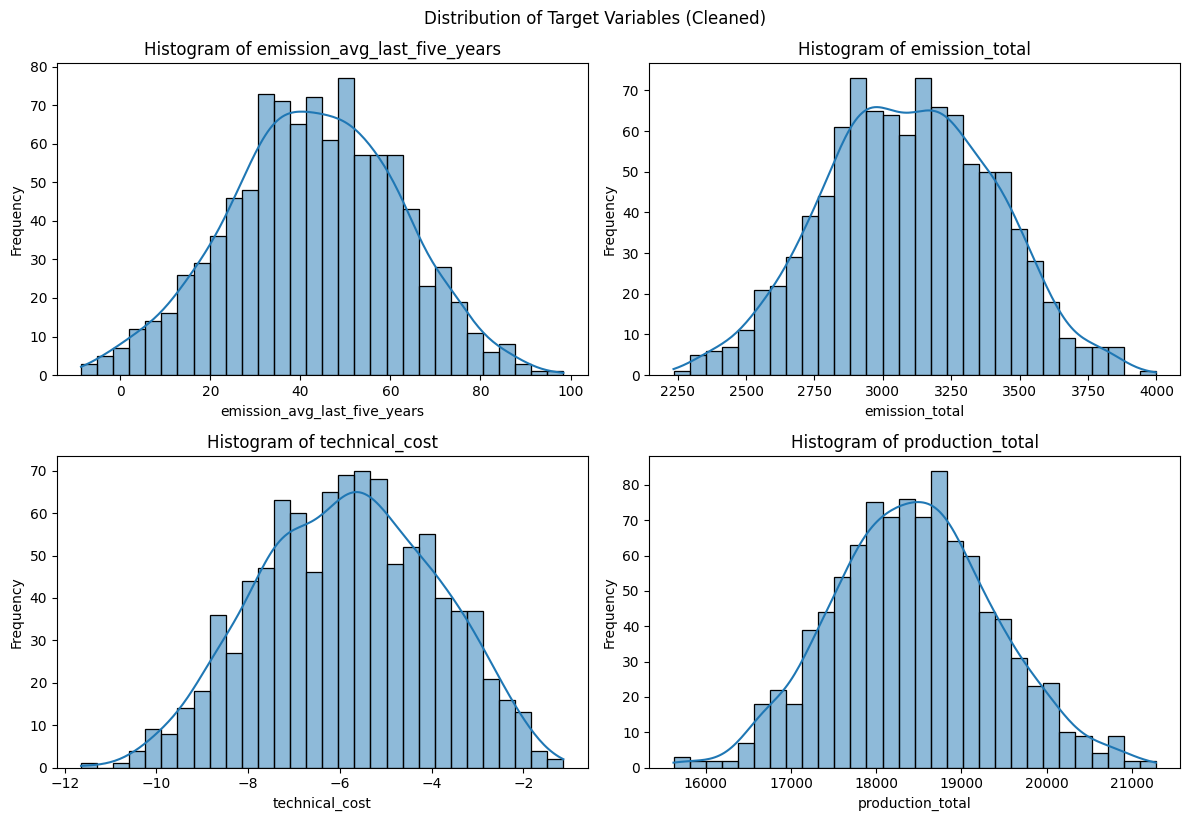

In [17]:
edau.plot_multiple_histograms(training_df_cleaned, target_cols, title="Distribution of Target Variables (Cleaned)")

In [18]:
outliers = edau.find_outlier_columns(training_df_cleaned, z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {'technical_cost': 0.10256410256410256}


In [19]:
edau.get_target_var_corr(training_df_cleaned, "emission_total")
edau.get_target_var_corr(training_df_cleaned, "emission_avg_last_five_years")
edau.get_target_var_corr(training_df_cleaned, "technical_cost")
edau.get_target_var_corr(training_df_cleaned, "production_total")


Correlation with target variable 'emission_total' (threshold: 0.1):
--------------------------------------------------
emission_total                 : 1.0000
emission_avg_last_five_years   : 0.9800
group_34_nemomod_en            : 0.7311
group_26_frac_inen_energy      : 0.3842
group_17_frac_trns_fuelmix     : 0.3032
group_5_efficfactor_enfu_industrial_energy_fuel : 0.1970
production_total               : 0.1872
group_4_demscalar_ippu         : 0.1491
group_47_scalar_scoe_heat_energy_demand : 0.1027


Correlation with target variable 'emission_avg_last_five_years' (threshold: 0.1):
--------------------------------------------------
emission_avg_last_five_years   : 1.0000
emission_total                 : 0.9800
group_34_nemomod_en            : 0.6268
group_26_frac_inen_energy      : 0.3981
group_17_frac_trns_fuelmix     : 0.3923
production_total               : 0.2660
group_4_demscalar_ippu         : 0.2248
group_5_efficfactor_enfu_industrial_energy_fuel : 0.1378
group_19_frac_trns_pkm

In [20]:
training_df_cleaned[target_cols].describe()

,emission_avg_last_five_years,emission_total,technical_cost,production_total
count,975.000000,975.000000,975.000000,975.000000
mean,42.911755,3095.612364,-5.838921,18443.599554
std,18.802249,308.132331,1.905005,947.539273
min,-8.721902,2234.745766,-11.643686,15622.695742
25%,30.631985,2877.883926,-7.259435,17806.869593
50%,42.939479,3095.834658,-5.790945,18421.569765
75%,56.413631,3316.242730,-4.412715,19053.604538
max,98.409631,3997.860060,-1.130138,21281.238128


In [23]:
# sns.pairplot(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

In [24]:
# edau.plot_correlation_matrix(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

## ML

### Individual Training

In [25]:
# negative_emissions_df = training_df_cleaned[lhs_group_cols + ["total_negative_emissions"]]
# positive_emissions_df = training_df_cleaned[lhs_group_cols + ["total_positive_emissions"]]


In [26]:
# negative_epp = EmissionsPredictionPipeline(
#     df=negative_emissions_df,
#     target="total_negative_emissions",
#     test_size=0.2,
#     random_state=42,
# )

# negative_epp.run(tune=False, log_transform=False, create_plots=False)

In [27]:
# positive_epp = EmissionsPredictionPipeline(
#     df=positive_emissions_df,
#     target="total_positive_emissions",
#     test_size=0.2,
#     random_state=42,
# )
# positive_epp.run(tune=False, log_transform=False, create_plots=False)

### Multi Output Training

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGB hyperparameters: {'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.5}

=== XGB ===
emission_total                
  Train → MAE: 23.7978, RMSE: 29.7935, R²: 0.9905, SMAPE: 0.8%
   Test → MAE: 96.3323, RMSE: 118.2952, R²: 0.8589, SMAPE: 3.1%
emission_avg_last_five_years  
  Train → MAE: 1.7517, RMSE: 2.1978, R²: 0.9861, SMAPE: 6.9%
   Test → MAE: 7.1508, RMSE: 8.7211, R²: 0.7962, SMAPE: 23.3%
technical_cost                
  Train → MAE: 0.0850, RMSE: 0.1077, R²: 0.9968, SMAPE: 1.6%
   Test → MAE: 0.2321, RMSE: 0.2911, R²: 0.9753, SMAPE: 4.4%
production_total              
  Train → MAE: 113.9254, RMSE: 142.2341, R²: 0.9778, SMAPE: 0.6%
   Test → MAE: 397.5623, RMSE: 479.7314, R²: 0.7230, SMAPE: 2.2%

=== MeanBaseline ===
emission_total                
  Train → MAE: 249.0873, RMSE: 306.1902, R²: 0.0000, SMAPE: 8.1%
   Test → MAE:

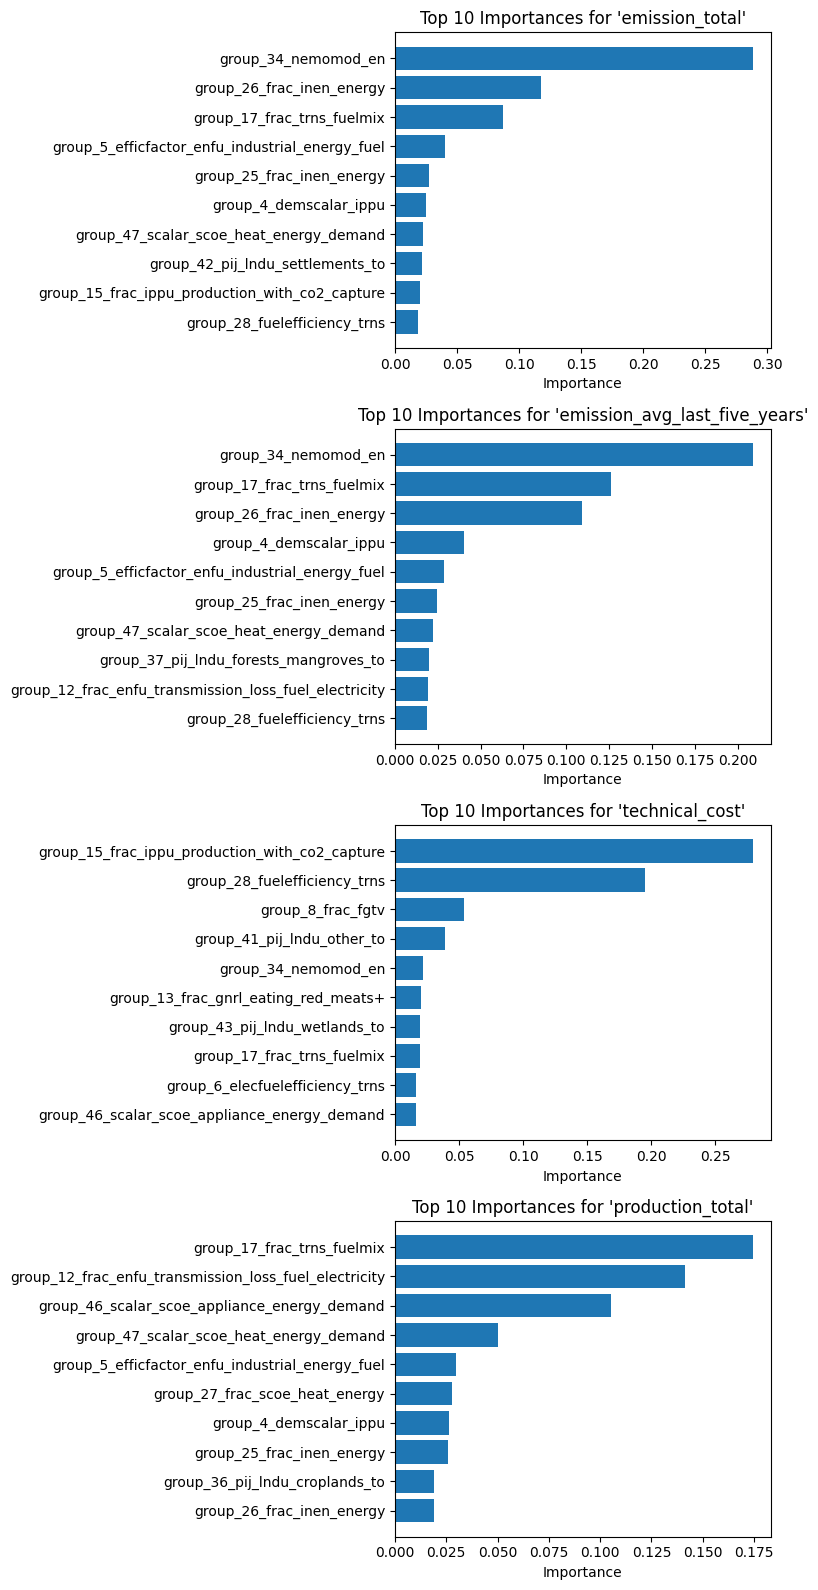

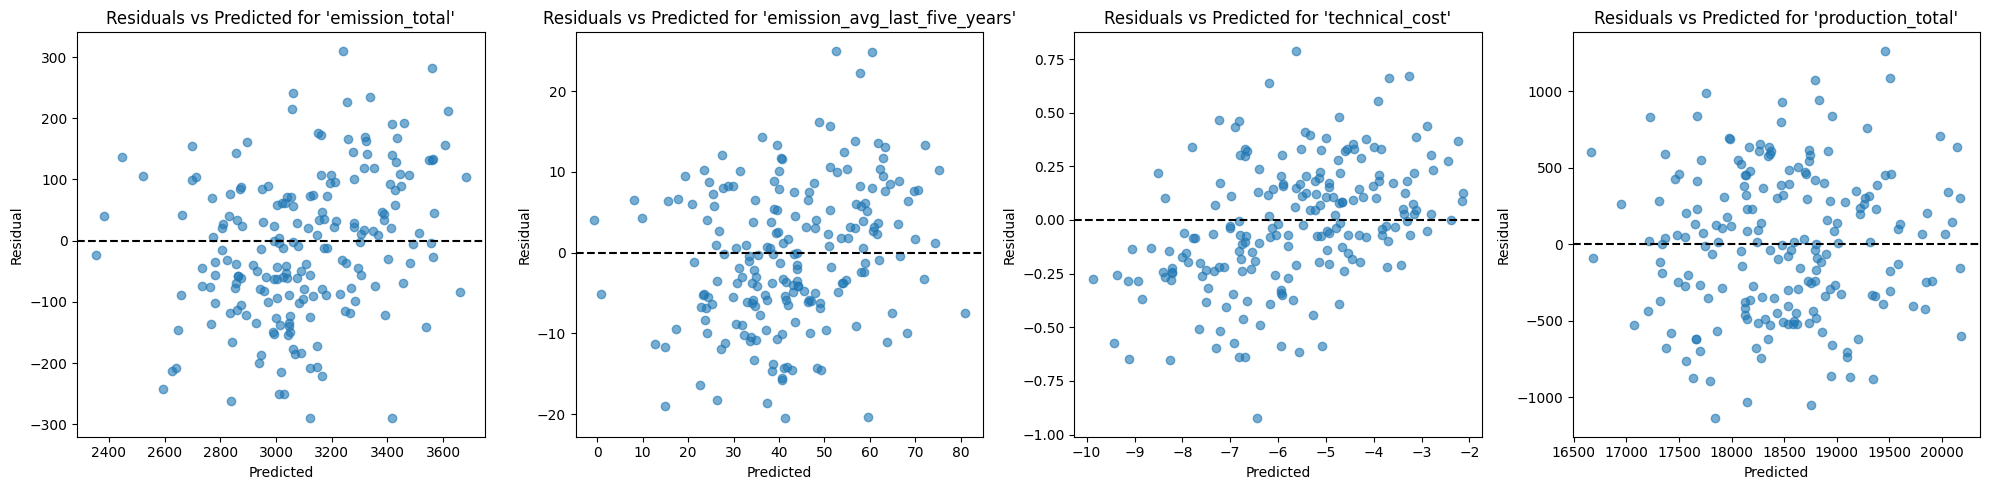

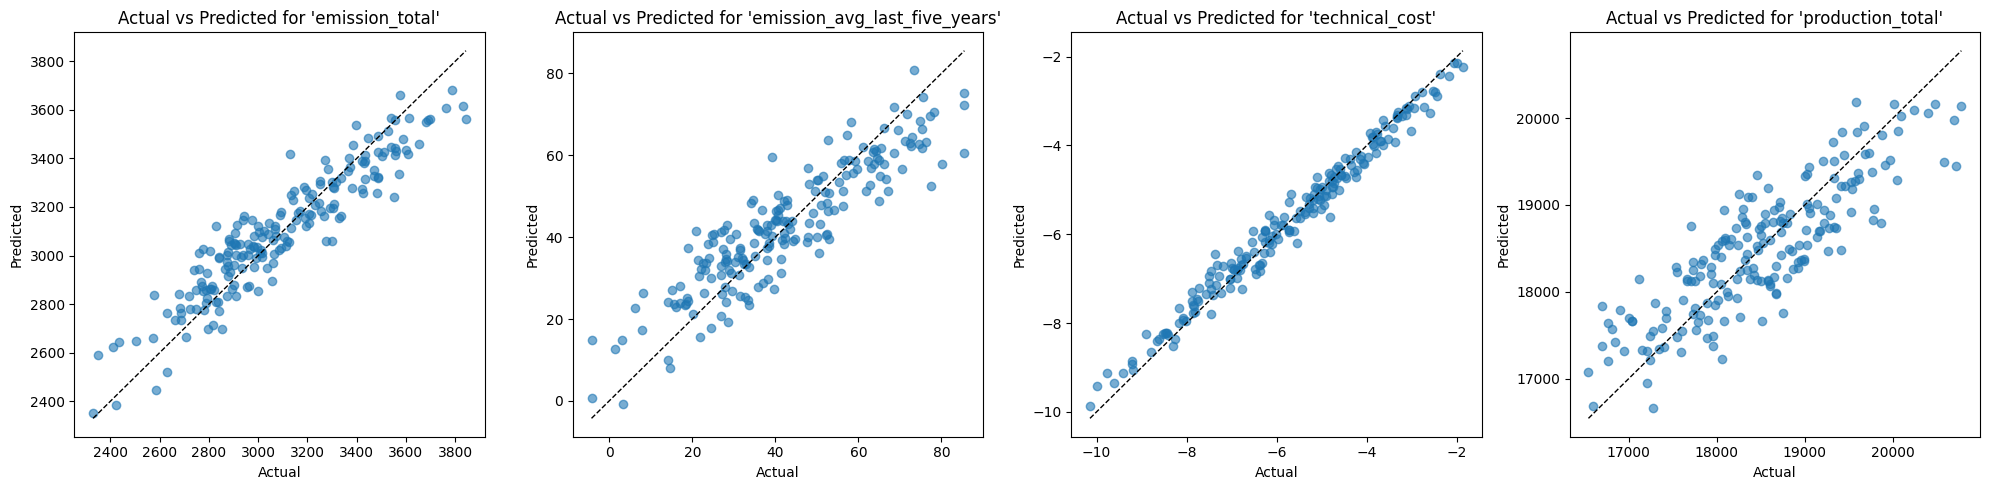

In [22]:
mulp = MultiOutputEmissionsPipeline(df=training_df_cleaned, targets=["emission_total", "emission_avg_last_five_years", "technical_cost", "production_total"])
mulp.run(tune=True, log_transform=False, plot_figures=True)

## Save the trained and tuned model and use it to predict new data

In [23]:
training_df_cleaned.head()

,group_1_ef_lvst_entferm,group_2_yf_agrc,group_3_demscalar_soil,group_4_demscalar_ippu,group_5_efficfactor_enfu_industrial_energy_fuel,group_6_elecfuelefficiency_trns,group_7_factor_waso_waste_per_capita_scalar_food,group_8_frac_fgtv,group_9_frac_agrc_agriculture_production_lost,group_10_frac_agrc,...,group_42_pij_lndu_settlements_to,group_43_pij_lndu_wetlands_to,group_44_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_45_scalar_lvst_carrying_capacity,group_46_scalar_scoe_appliance_energy_demand,group_47_scalar_scoe_heat_energy_demand,emission_avg_last_five_years,emission_total,production_total,technical_cost
0,0.952436,0.360397,0.202990,0.995748,0.369859,0.919920,0.478450,0.445798,0.490988,0.510280,...,0.053597,0.175103,0.379422,0.438093,0.149362,0.869757,52.248688,3318.009812,19378.180701,-5.143090
1,0.304955,0.204875,0.540658,0.800192,0.206396,0.777352,0.805727,0.536048,0.779857,0.623335,...,0.246165,0.101025,0.717013,0.368791,0.774941,0.483352,49.914523,3219.904574,18029.696308,-6.899667
2,0.609262,0.366443,0.601808,0.916668,0.386475,0.181162,0.138910,0.768925,0.884425,0.232722,...,0.122444,0.653845,0.216259,0.714853,0.881270,0.581230,-5.154870,2328.191406,18788.752879,-7.129115
3,0.815313,0.487444,0.323954,0.634299,0.064625,0.926815,0.633805,0.439346,0.027114,0.532020,...,0.592915,0.564895,0.027725,0.138890,0.820709,0.250616,45.879563,3225.387997,18792.286140,-5.769771
4,0.973878,0.842718,0.884382,0.483039,0.455502,0.003343,0.571994,0.108021,0.346714,0.892123,...,0.432240,0.662820,0.179231,0.631375,0.395960,0.661637,24.993688,2740.854420,18030.008356,-8.530492


In [24]:
# Get a single row from training_df_cleaned for prediction
single_row = training_df_cleaned.iloc[0].drop(["emission_total", "emission_avg_last_five_years", "technical_cost", "production_total"])
single_row = single_row.to_frame().T  # Convert to DataFrame
single_row

,group_1_ef_lvst_entferm,group_2_yf_agrc,group_3_demscalar_soil,group_4_demscalar_ippu,group_5_efficfactor_enfu_industrial_energy_fuel,group_6_elecfuelefficiency_trns,group_7_factor_waso_waste_per_capita_scalar_food,group_8_frac_fgtv,group_9_frac_agrc_agriculture_production_lost,group_10_frac_agrc,...,group_38_pij_lndu_forests_primary_to,group_39_pij_lndu_forests_secondary_to,group_40_pij_lndu_grasslands+,group_41_pij_lndu_other_to,group_42_pij_lndu_settlements_to,group_43_pij_lndu_wetlands_to,group_44_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_45_scalar_lvst_carrying_capacity,group_46_scalar_scoe_appliance_energy_demand,group_47_scalar_scoe_heat_energy_demand
0,0.952436,0.360397,0.20299,0.995748,0.369859,0.91992,0.47845,0.445798,0.490988,0.51028,...,0.941385,0.873715,0.289038,0.996557,0.053597,0.175103,0.379422,0.438093,0.149362,0.869757


In [25]:
# Predict using the trained model
predictions = mulp.predict(single_row)
print("Predictions for single row:")
print(predictions)

Predictions for single row:
   emission_total  emission_avg_last_five_years  technical_cost  \
0     3335.966797                     52.616585       -5.107443   

   production_total  
0        19302.1875  


In [26]:
# Save the trained model
xgb_pipeline = mulp.pipelines["XGB"]
TRAINED_MODELS_DIR = os.path.join(SCRIPT_DIR_PATH, "trained_models")
model_file_name = "xgb_pipeline_5.1_narrative_profiles.pkl"
os.makedirs(TRAINED_MODELS_DIR, exist_ok=True)

MODEL_PATH = os.path.join(TRAINED_MODELS_DIR, model_file_name)
if os.path.exists(MODEL_PATH):
    print(f"Model {model_file_name} already exists at {MODEL_PATH}. Make sure you don't overwrite an existing model.")
else:
    print(f"Saving model {model_file_name} to {MODEL_PATH}.")
    joblib.dump(xgb_pipeline, MODEL_PATH)


Saving model xgb_pipeline_5.1_narrative_profiles.pkl to e:\Current_2023\WI\work\ssp_louisiana\metamodel\notebooks\trained_models\xgb_pipeline_5.1_narrative_profiles.pkl.


In [34]:
TRAINED_MODELS_DIR = Path(TRAINED_MODELS_DIR)

In [35]:

mulp.X_test.to_parquet(TRAINED_MODELS_DIR / "xgb_pipeline_5.1_narrative_profiles_X_test.parquet")
mulp.y_test.to_parquet(TRAINED_MODELS_DIR/"xgb_pipeline_5.1_narrative_profiles_y_test.parquet")

In [27]:
# Load the trained model and test predictions
xgb_pipeline_loaded = joblib.load(MODEL_PATH)

In [28]:
# Predict using the trained model
predictions = mulp.predict(single_row, ml_pipeline=xgb_pipeline_loaded)
print("Predictions for single row:")
print(predictions)

Predictions for single row:
   emission_total  emission_avg_last_five_years  technical_cost  \
0     3335.966797                     52.616585       -5.107443   

   production_total  
0        19302.1875  


e:\Current_2023\WI\work\ssp_louisiana\metamodel\notebooks\utils\narrative_profiles_utils.py:84: RuntimeWarning: overflow encountered in expm1
  y_pred = np.expm1(y_pred)


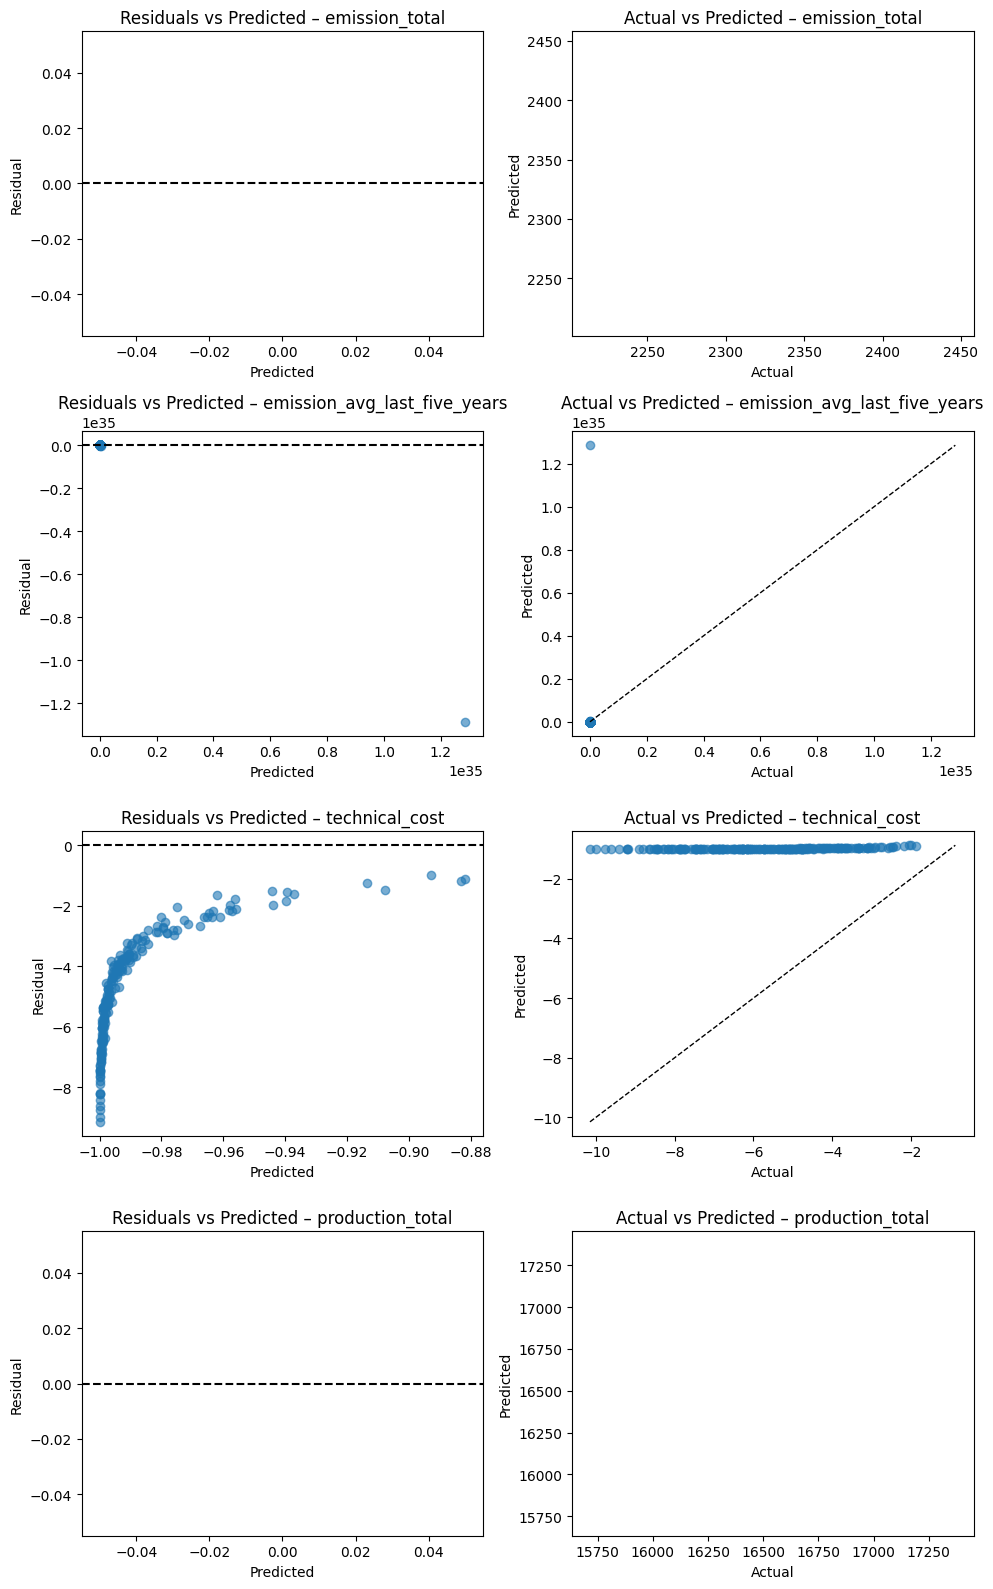

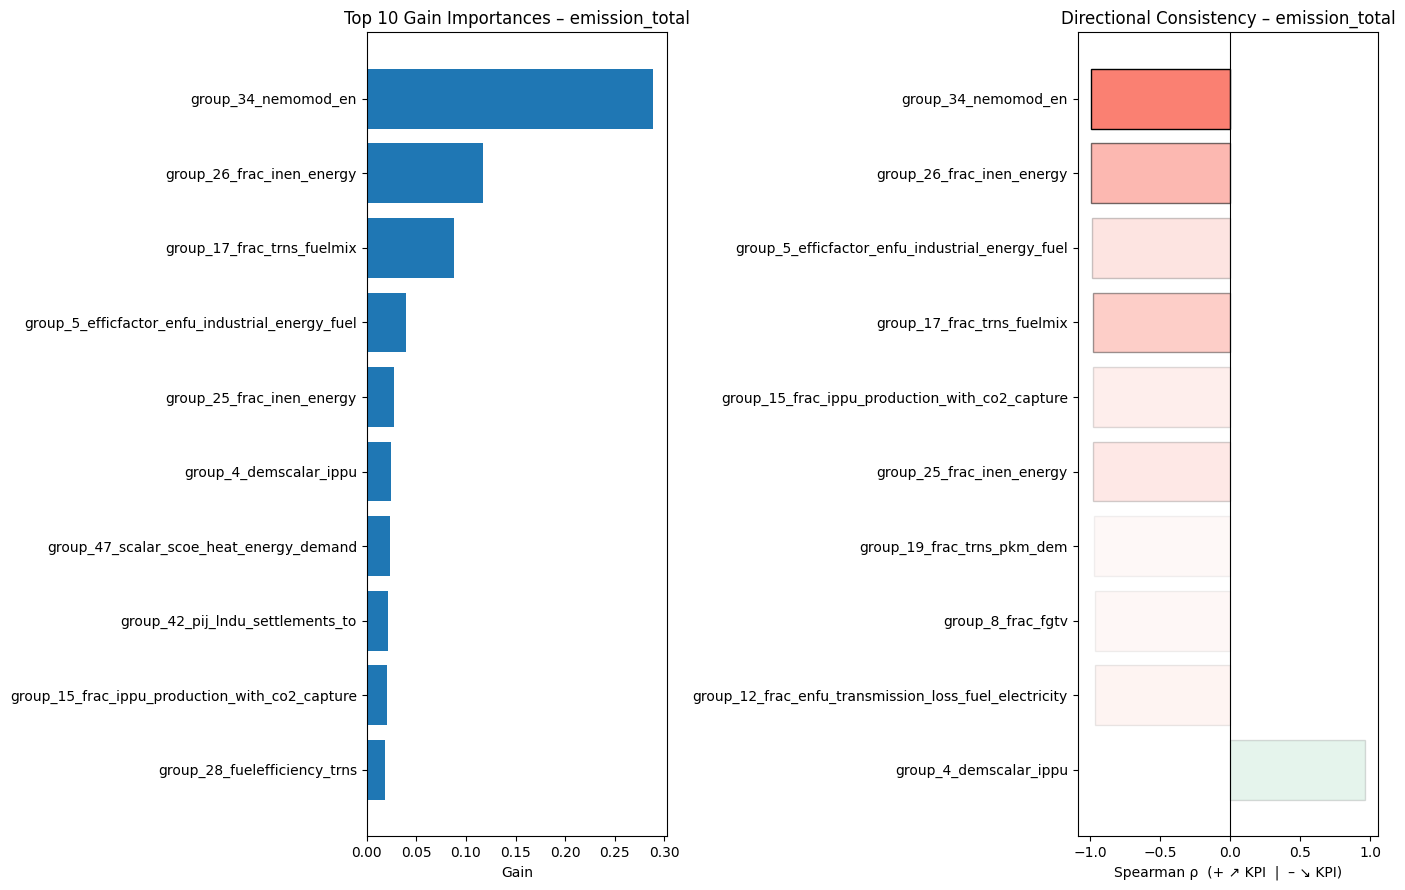

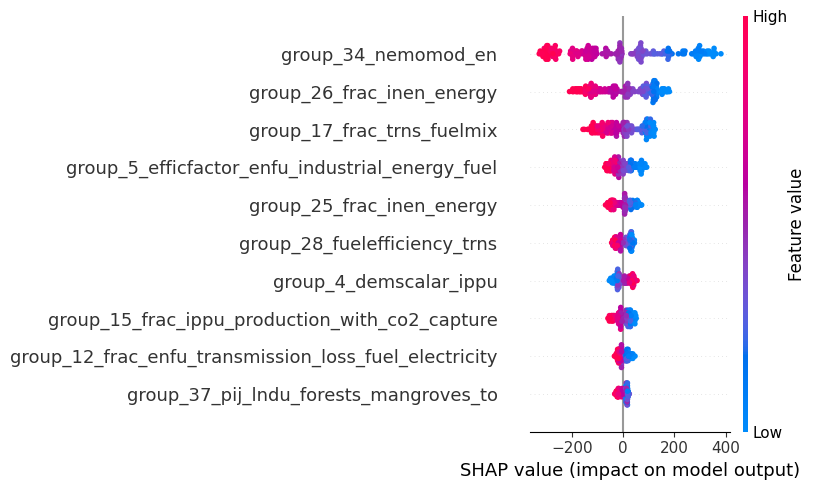

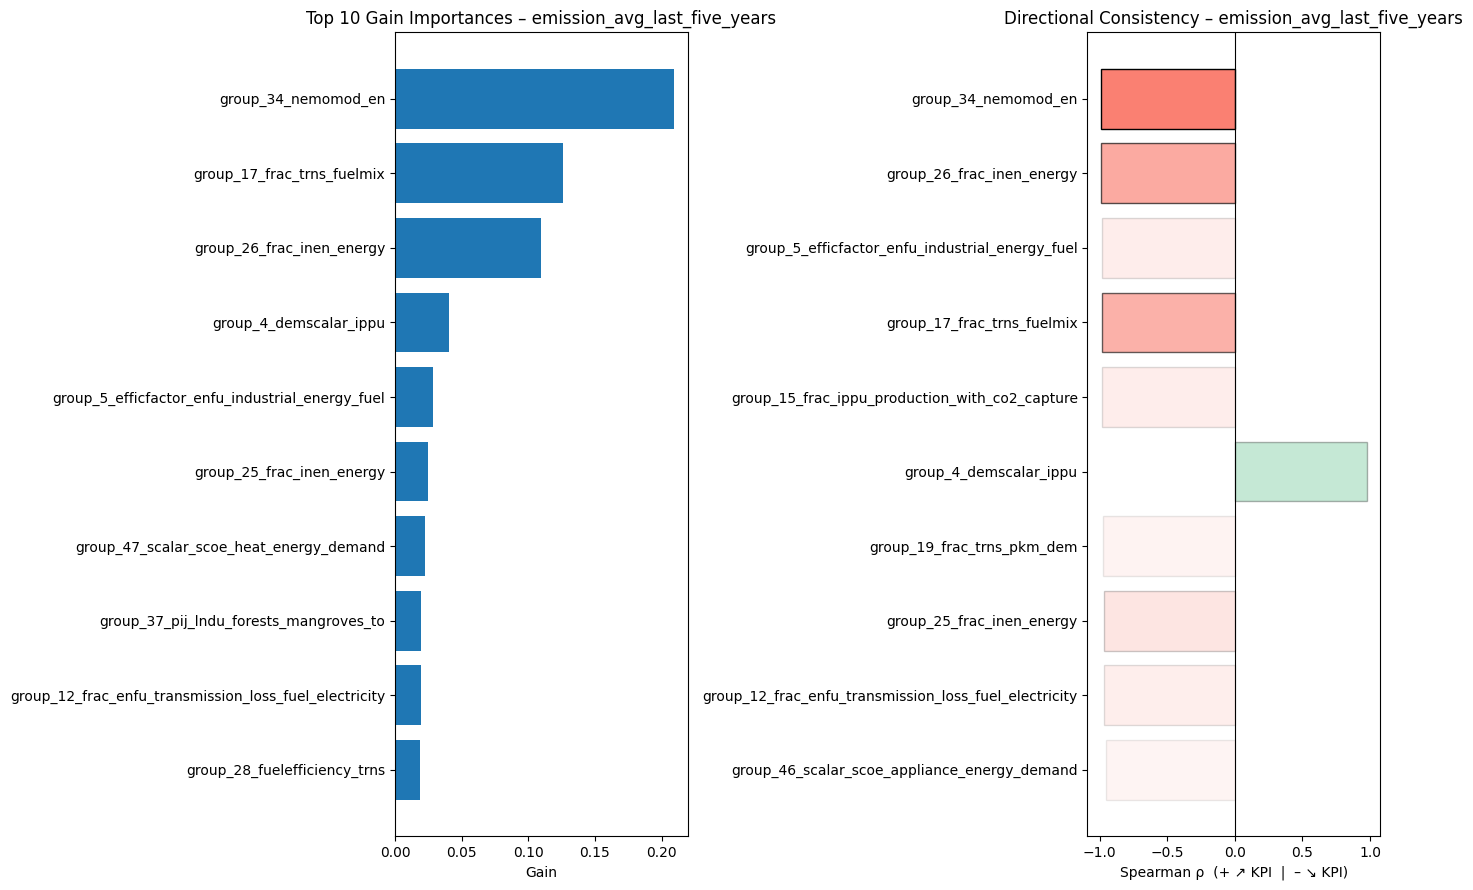

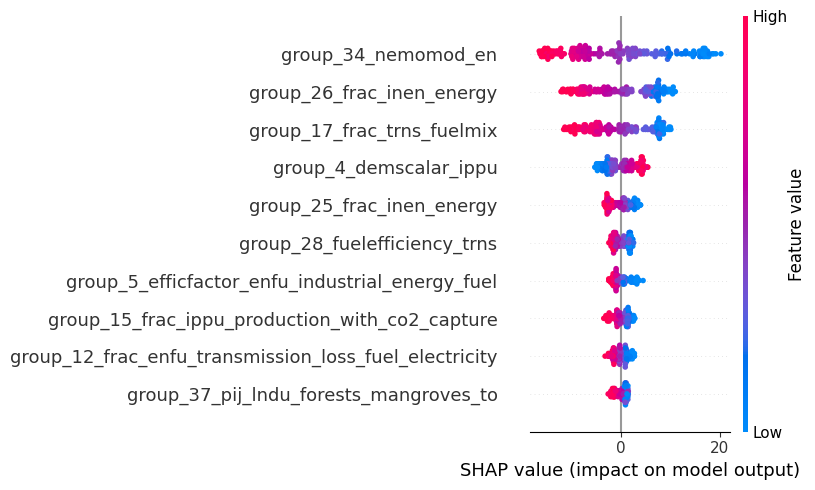

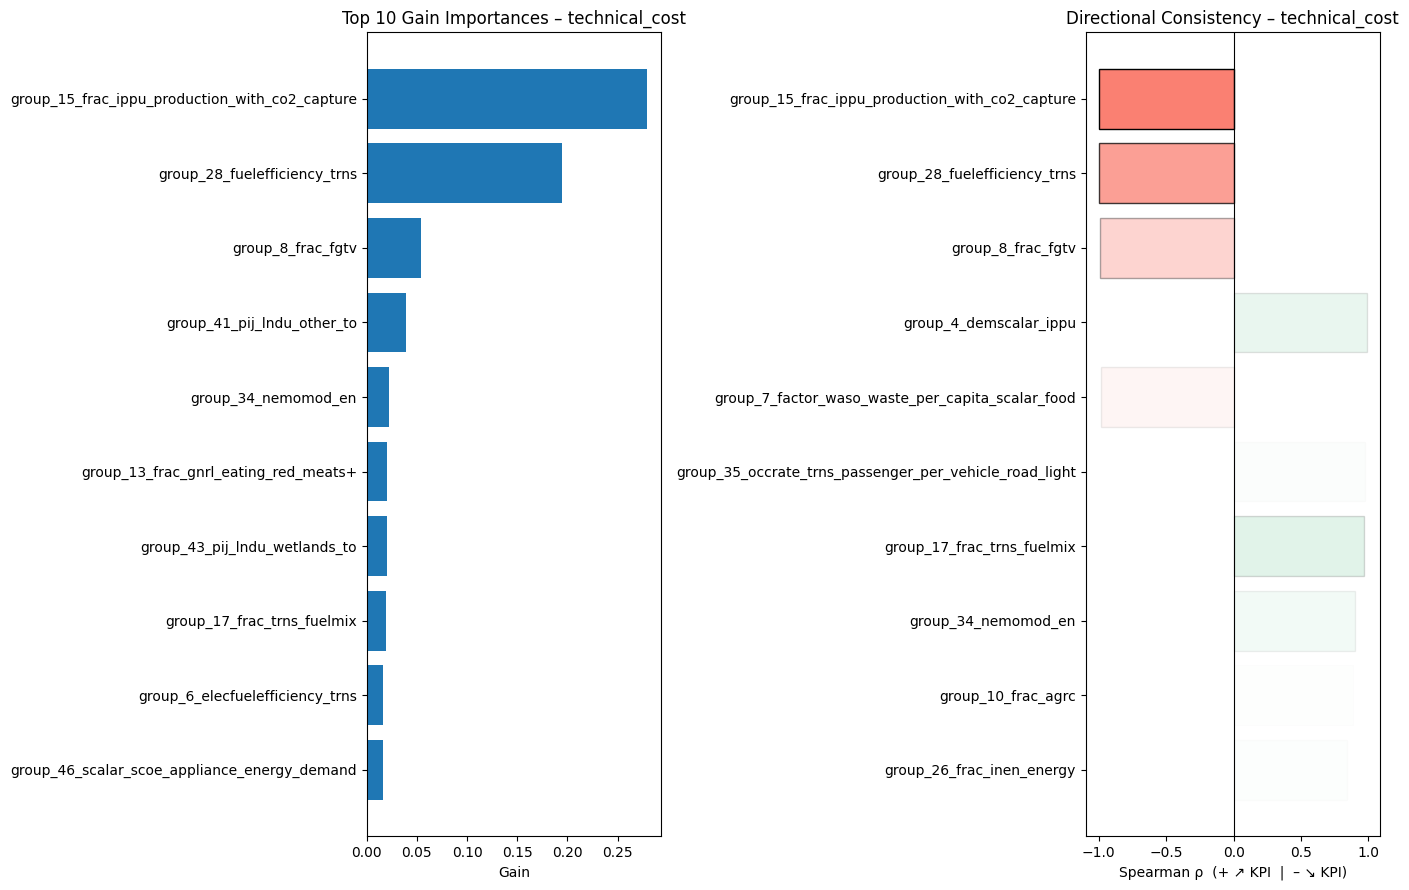

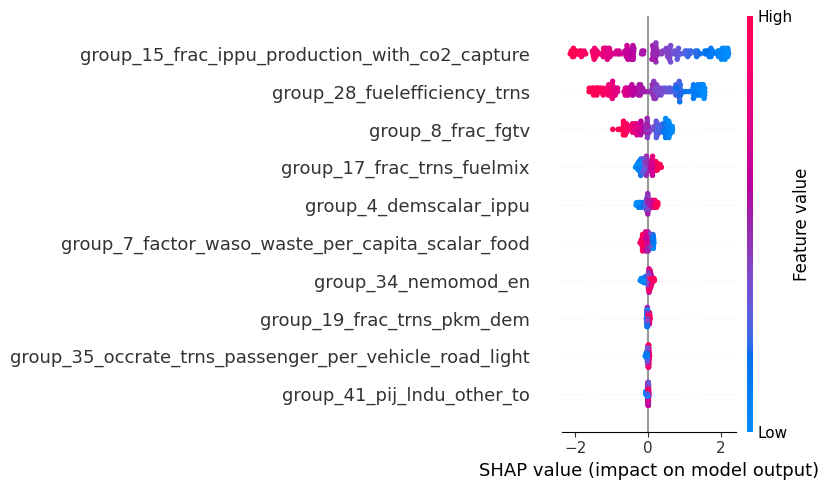

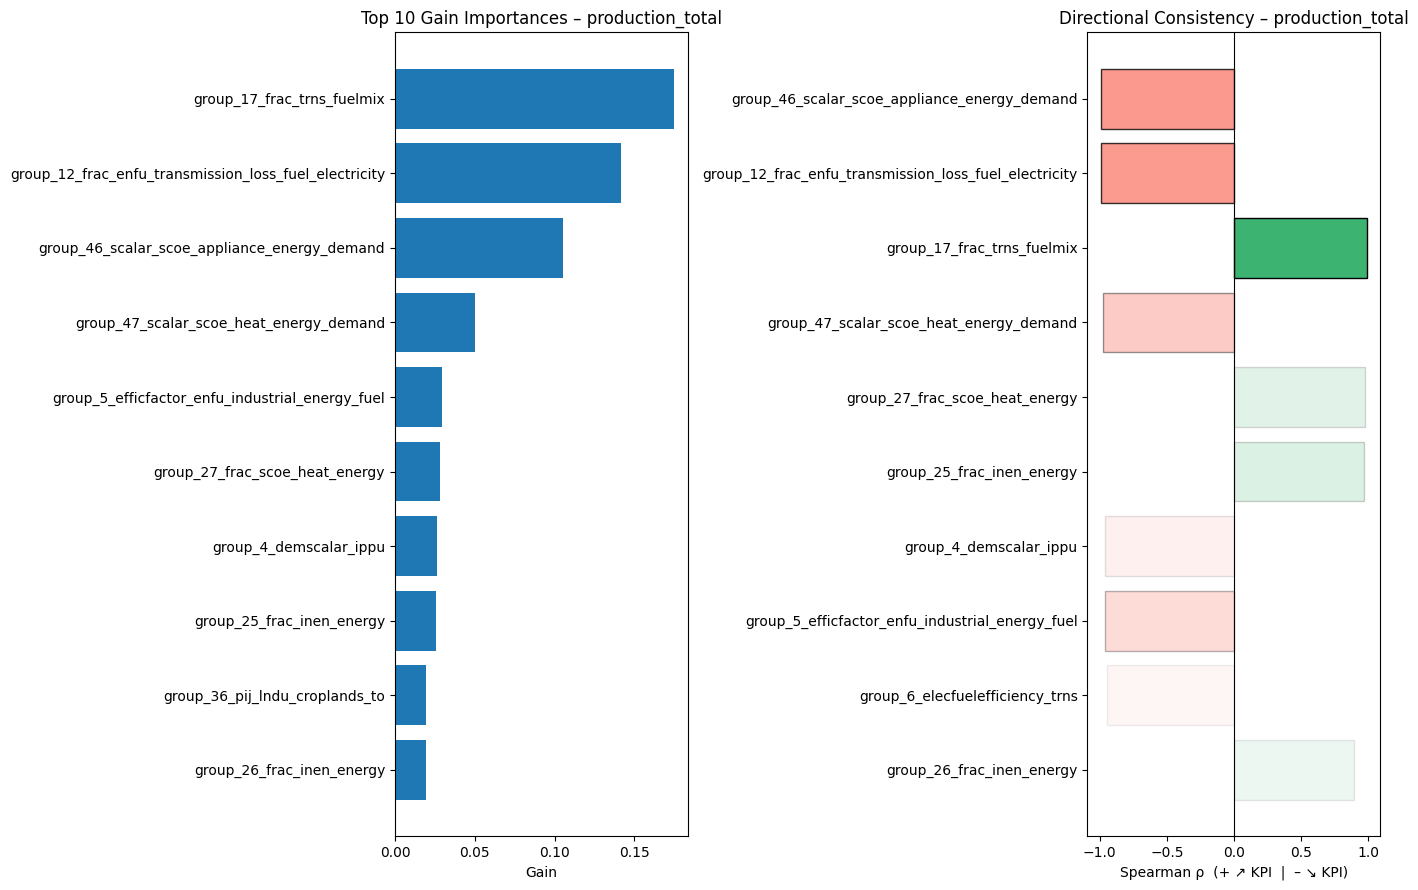

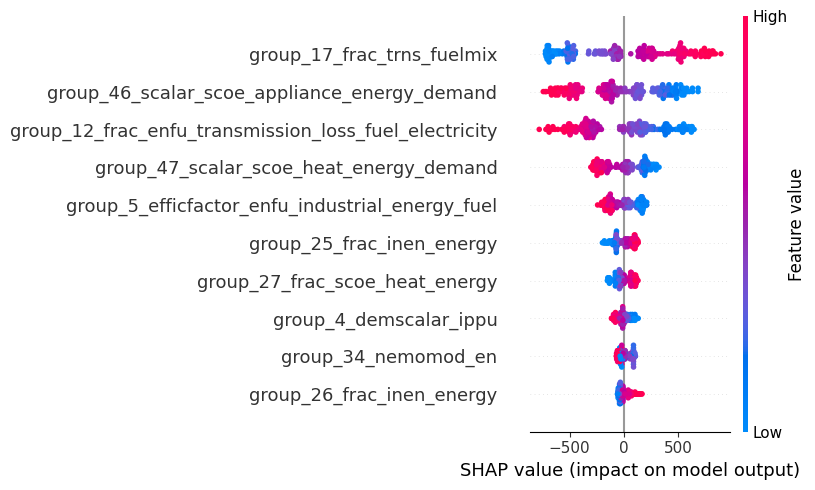

In [36]:
import joblib, pandas as pd
from utils.narrative_profiles_utils import plot_shap_diagnostics

# load artefacts
pipeline = joblib.load(MODEL_PATH)   # your trained Pipeline
X_test   = pd.read_parquet(TRAINED_MODELS_DIR / "xgb_pipeline_5.1_narrative_profiles_X_test.parquet")
y_test   = pd.read_parquet(TRAINED_MODELS_DIR/"xgb_pipeline_5.1_narrative_profiles_y_test.parquet")
targets  = ["emission_total", "emission_avg_last_five_years", "technical_cost", "production_total"]                   # order matches training

# fire up the visuals
plot_shap_diagnostics(
    pipeline,
    X_test,
    y_test,
    targets,
    log_transform=True,   # set True if targets were log-transformed during fit
    top_n=10              # number of features to show in bar/beeswarm charts
)
